In [1]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=2.5)

In [2]:
#n_states, start_width, delta, measurement_prob,  I, J, steps = 11, 3, 0.5, 0.8, 1, 1, 0.1
n_states, start_width, response_width, delta, measurement_prob,  I, J, steps = 7, None, 1, 0.2, 0.8, 1, 1, 0.1
start_width = (n_states-2*response_width)-2 #(n_states-2*response_width)//2 #
prior_types="Centered"
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")
n_states, start_width, response_width

(7, 3, 1)

In [3]:
#m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
#q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100

m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[5]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [4]:
intensity_matrix_markov

Array([[[[-1.,  0.,  0.,  0.,  0.,  0.,  0.],
         [ 1., -1.,  0.,  0.,  0.,  0.,  0.],
         [ 0.,  1., -1.,  0.,  0.,  0.,  0.],
         [ 0.,  0.,  1., -1.,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  1., -1.,  0.,  0.],
         [ 0.,  0.,  0.,  0.,  1., -1.,  1.],
         [ 0.,  0.,  0.,  0.,  0.,  1., -1.]]]], dtype=float64)

In [5]:
ca._get_transition_matrix(intensity_matrix_markov, RT=delta, delta=delta, Mn=m_Mn, transition_type="RT").squeeze().round(decimals=2)

Array([[0.82, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.16, 0.82, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.02, 0.16, 0.82, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.02, 0.16, 0.82, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.02, 0.16, 0.82, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.02, 0.16, 0.84, 0.16],
       [0.  , 0.  , 0.  , 0.  , 0.02, 0.16, 0.84]], dtype=float64)

In [6]:
(np.abs(ca._get_transition_matrix(intensity_matrix_quantum, RT=delta, delta=delta, Mn=q_Mn, transition_type="RT").squeeze())**2).round(decimals=3)

array([[0.334, 0.497, 0.149, 0.018, 0.001, 0.   , 0.   ],
       [0.497, 0.037, 0.325, 0.123, 0.016, 0.001, 0.   ],
       [0.149, 0.325, 0.052, 0.333, 0.124, 0.016, 0.001],
       [0.018, 0.123, 0.333, 0.051, 0.333, 0.123, 0.018],
       [0.001, 0.016, 0.124, 0.333, 0.052, 0.325, 0.149],
       [0.   , 0.001, 0.016, 0.123, 0.325, 0.037, 0.497],
       [0.   , 0.   , 0.001, 0.018, 0.149, 0.497, 0.334]])

<Axes: >

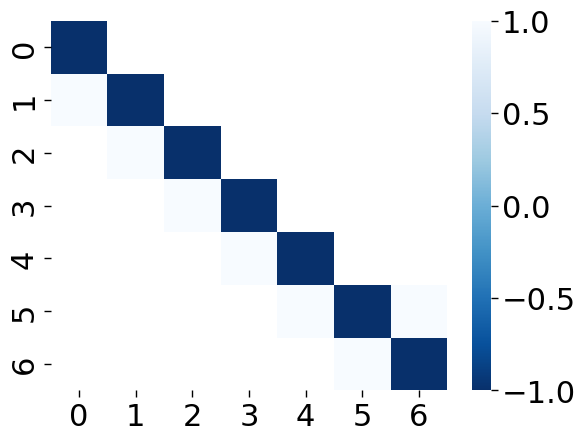

In [7]:

sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) , cmap = "Blues_r")

In [8]:
np.imag(np.where(intensity_matrix_quantum.squeeze()==0,np.nan,intensity_matrix_quantum.squeeze()) )

array([[ 3., -5.,  0.,  0.,  0.,  0.,  0.],
       [-5.,  2., -5.,  0.,  0.,  0.,  0.],
       [ 0., -5.,  1., -5.,  0.,  0.,  0.],
       [ 0.,  0., -5.,  0., -5.,  0.,  0.],
       [ 0.,  0.,  0., -5., -1., -5.,  0.],
       [ 0.,  0.,  0.,  0., -5., -2., -5.],
       [ 0.,  0.,  0.,  0.,  0., -5., -3.]])

<Axes: >

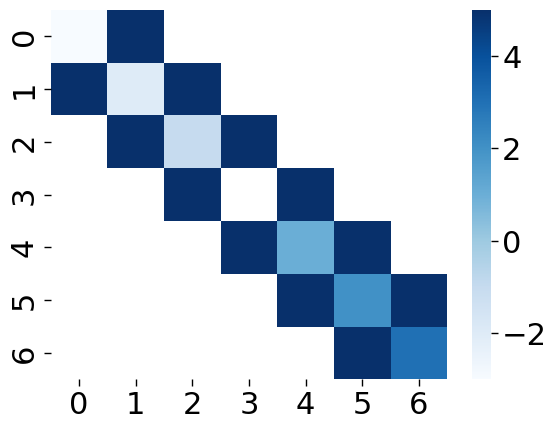

In [9]:
intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = "Blues")

In [10]:
phi_0_markov = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.        ],
          [0.        ],
          [0.        ],
          [0.        ],
          [0.33333333],
          [0.33333333],
          [0.33333333]]]], dtype=float64),
 Array([[[[0.        ],
          [0.        ],
          [0.        ],
          [0.        ],
          [0.57735027],
          [0.57735027],
          [0.57735027]]]], dtype=float64))

In [11]:
phi_0_markov

Array([[[[0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.33333333],
         [0.33333333],
         [0.33333333]]]], dtype=float64)

In [12]:
ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[0.5]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

Array([[[[0.        ],
         [0.        ],
         [0.        ],
         [0.        ],
         [0.20217689],
         [0.43868676],
         [0.35913635]]]], dtype=float64)

In [13]:
delta

0.2

phi_0_quantum = npx.array([[[[0.06871463],
         [0.07356508],
         [0.08124495],
         [0.10388036],
         [0.12732417],
         [0.11843169],
         [0.10549717],
         [0.09700889],
         [0.08124495],
         [0.06911884],
         [0.07396928]]]])
phi_0_quantum.shape

In [14]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in [prior_types]: #"Upper", "All", "Lower", "Centered"
    phi_0_markov = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
    
    for t in np.arange(1,5/delta,delta):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="TIMESTEP", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,5/delta,delta):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="TIMESTEP", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [15]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-3,Centered,0.0,-0.052816673446921245,-0.13440802009564046
1,-2,Centered,0.0,0.11902387335343588,-0.05322306384668214
2,-1,Centered,0.0,-0.0634634758623367,-0.12967281697767247
3,0,Centered,0.0,-0.07495348597303646,-0.12230126682677678
4,1,Centered,0.0,-0.3388113252049081,0.007371550150895856
...,...,...,...,...,...
835,-1,Centered,11.9,-9.650384342187811e-08,-9.033656302245077e-09
836,0,Centered,11.9,-6.32349969130351e-08,3.135069488969161e-08
837,1,Centered,11.9,-1.417456747505483e-07,4.0384351191938826e-08
838,2,Centered,11.9,-1.0148473243370152e-07,7.87674281532141e-08


In [16]:
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [17]:
import plotly.express as px
pio.renderers.default = "browser" #"vscode" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", title = 'Random Walk - Probability "Amplitude" (Participant #1)',
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Conf States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
#fig.show()
#import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

df_quantum_3d.query("states == 6 and prior == 'Upper' and time > 10 and time < 100")

intensity_matrix_markov

pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

In [18]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered"}))

with sns.plotting_context("talk",font_scale=1.2):
    f = sns.relplot(df_markov_plot
                    .query("time <= 6 and prior == 'Uniform'")
                    ,alpha=0.8,
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=2.3, height=4.3)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("Confidence States")
    f.set(ylim=(-3.99, 3.99))

with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_markov_plot
                    .query("time <= 5")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()


with sns.plotting_context("talk",font_scale=1.2):
    f = sns.relplot(df_quantum_plot
                    .query("time <= 20 and prior == 'Uniform'")
                    ,alpha=0.8,
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=2.3, height=4.3)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("Confidence States")
    f.set(ylim=(-5.5, 5.5))

with sns.plotting_context("talk",font_scale=1.9):
    f = sns.relplot(pd.concat([df_markov_plot.assign(model="Diffusion"), df_quantum_plot.assign(model="Quantum")])
                    .query("time <= 20 and prior == 'Uniform'")
                    ,alpha=0.8, row="model", 
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=3.3, height=5)
    f.set_titles("{row_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("Conf States")
    #f.set(ylim=(-5.5, 5.5))


with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_quantum_plot
                    .query("time <= 15")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [19]:
df_plot = pd.concat([df_markov_plot.assign(type="Markov Random-Walk Model"), df_quantum_plot.assign(type="Quantum Random-Walk Model")])
df_plot

,states,prior,time,value,type
0,-3,Centered,0.0,0.000000e+00,Markov Random-Walk Model
1,-2,Centered,0.0,0.000000e+00,Markov Random-Walk Model
2,-1,Centered,0.0,3.333333e-01,Markov Random-Walk Model
3,0,Centered,0.0,3.333333e-01,Markov Random-Walk Model
4,1,Centered,0.0,3.333333e-01,Markov Random-Walk Model
...,...,...,...,...,...
842,-1,Centered,24.0,9.394599e-15,Quantum Random-Walk Model
843,0,Centered,24.0,4.981531e-15,Quantum Random-Walk Model
844,1,Centered,24.0,2.172273e-14,Quantum Random-Walk Model
845,2,Centered,24.0,1.650346e-14,Quantum Random-Walk Model


with sns.plotting_context(font_scale=1):
    f = sns.relplot(df_plot
                    .query("time <= 20 ")
                    ,alpha=0.8, row="type", col="prior", sizes=(40,700), 
    x="time", y="states",size="value", color="Black", aspect=2, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

df_plot

In [20]:
df_plot.query("prior == 'Centered' and time <= 8 ")

,states,prior,time,value,type
0,-3,Centered,0.0,0.000000,Markov Random-Walk Model
1,-2,Centered,0.0,0.000000,Markov Random-Walk Model
2,-1,Centered,0.0,0.333333,Markov Random-Walk Model
3,0,Centered,0.0,0.333333,Markov Random-Walk Model
4,1,Centered,0.0,0.333333,Markov Random-Walk Model
...,...,...,...,...,...
282,-1,Centered,8.0,0.000001,Quantum Random-Walk Model
283,0,Centered,8.0,0.000003,Quantum Random-Walk Model
284,1,Centered,8.0,0.000004,Quantum Random-Walk Model
285,2,Centered,8.0,0.000005,Quantum Random-Walk Model


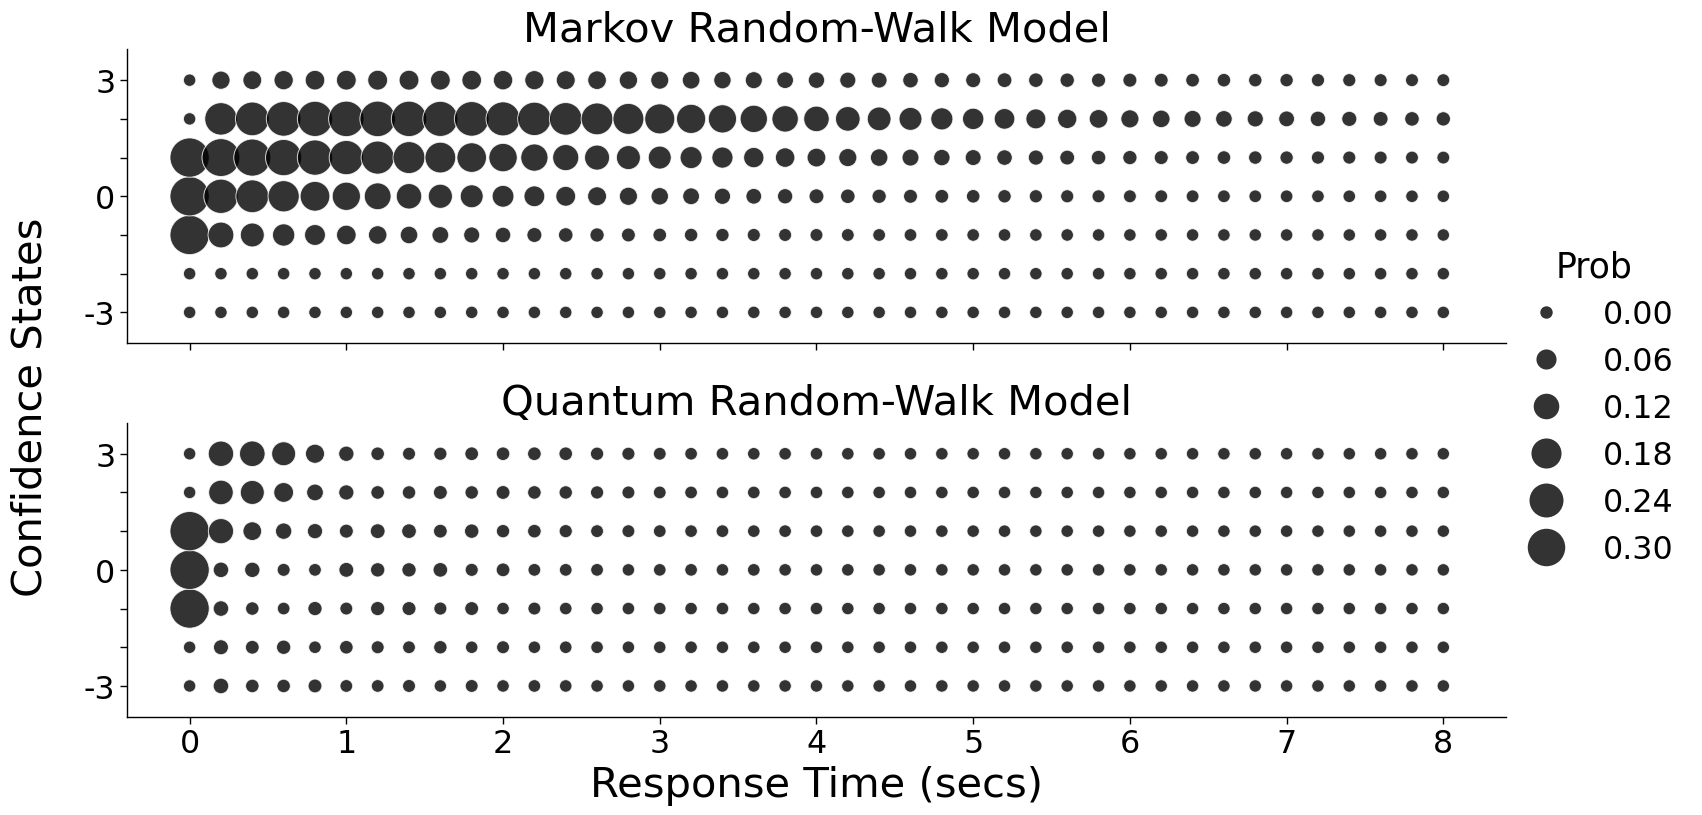

In [21]:
with sns.plotting_context("paper",font_scale=2.6):
    f = sns.relplot(df_plot
                    .query("time <= 8 ") #prior == 'Centered' and 
                    ,alpha=0.8, col="type", col_wrap=1, sizes=(80,800), 
    x="time", y="states",size="value", color="Black", aspect=3.6, height=4.3)
    f.set_titles("{col_name}", size=30)
    f.legend.set_title("Prob")
    f.set_xlabels("Response Time (secs)", fontsize=30)
    f.set_ylabels("")
    f.figure.supylabel("Confidence States", fontsize=30)
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-3.8, 3.8))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [22]:
import matplotlib as mpl
mpl.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

In [23]:
mid = int(n_states+1)/2

states_ticks = np.arange(-(mid-1), mid)
states_labels = (states_ticks + (5 * np.sign(states_ticks))) * 10
states_labels

array([-80., -70., -60.,   0.,  60.,  70.,  80.])

df_quantum_plot.groupby(["time", "prior"], sort=False)[["value", "states"]].apply(lambda df: df.value * df.states)#.values

def test(df):
    #print((df.value * df.state_labels).values.shape)
    return (df.value * df.state_labels).values
df_quantum_plot.query("prior=='Uniform' and time < 15") \
.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ) \
.assign(mean_conf = lambda df: df.groupby(["time", "prior"], sort=False)[["value", "state_labels"]].apply(lambda df: df.value * df.state_labels).values)

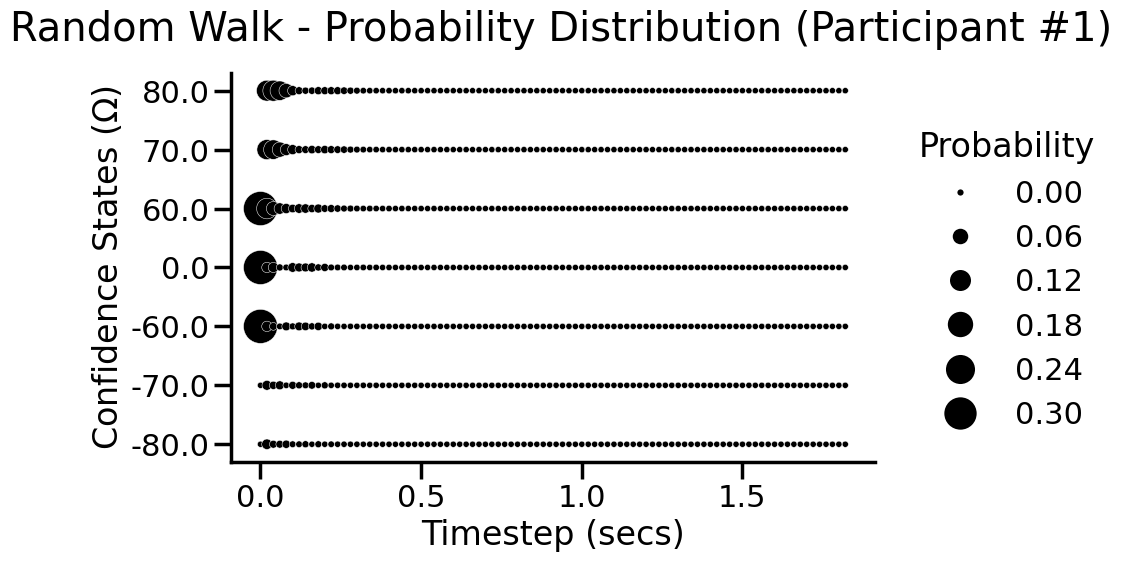

In [24]:
with sns.plotting_context(context="poster"): #prior=='Centered' and 
    f = sns.relplot(df_quantum_plot.query("time < 18.24").assign(time = lambda df: df.time * 0.1), 
    x="time", y="states",size="value", legend=True, sizes=(20,600), aspect=1.5, color="black", height=5.5 )
    f.set(yticks = states_ticks)
    f.set_yticklabels(labels=states_labels)
    f.set_ylabels(r"Confidence States $(\Omega)$")
    f.set_xlabels("Timestep (secs)")
    f.legend.set_title("Probability")
    f.figure.suptitle("Random Walk - Probability Distribution (Participant #1)", y=1.05)


fig = px.scatter(df_quantum_plot.query("prior=='Uniform'"), x="time", y="states",size="value")
fig.update_layout( 
    scene=dict(aspectratio = dict( x=1, y=0.1 ),
    aspectmode = 'manual'),
    autosize=True)

f = sns.relplot(df_quantum_plot.astype({"states":"category"}),
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1, height = 4.5)
f.set_titles("{col_name}")
f.legend.set_title("Probability")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_loc("lower right")

In [39]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

array([-3, -2, -1,  0,  1,  2,  3])

In [26]:
start_width

3

In [27]:
steps=0.01
delta=steps

In [28]:
n_states, start_width, response_width,

(7, 3, 1)

In [29]:
m_sigma, q_sigma

(Array([[1]], dtype=int64), Array([[5]], dtype=int64))

n_states, start_width, response_width = 11, 5 ,2
#mv = np.asarray([-100,-90,-80,-70,-60, 0, 60, 70, 80,90,100])
start_width = (n_states-2*response_width)-2
mv = np.arange(-(n_states//2), (n_states//2)+1)

start_width

In [30]:
n_states, (start_width:=3), response_width, (measurement_prob:=0.8), (steps := 0.01), (delta := 0.01) # configuration used for publication

(7, 3, 1, 0.8, 0.01, 0.01)

In [31]:
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, response_width, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, response_width, prob=measurement_prob, model_type = "Quantum")

In [41]:
mv_c = mv.copy()
mv_w = mv.copy()

mv_c[mv<0] = 0
mv_w[mv>0] = 0
mv_c, mv_w

(array([0, 0, 0, 0, 1, 2, 3]), array([-3, -2, -1,  0,  0,  0,  0]))

In [87]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

df_markov_internal_1 = pd.DataFrame()
df_quantum_internal_1 = pd.DataFrame()

df_markov_internal_c = pd.DataFrame()
df_quantum_internal_c = pd.DataFrame()

df_markov_internal_w = pd.DataFrame()
df_quantum_internal_w = pd.DataFrame()

for mu in [npx.asarray([[1]])]:#, npx.asarray([[-0.05]]), npx.asarray([[1]]), npx.asarray([[-1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_markov_i = dd._buildK(n_states, mu, m_sigma, boundary_type="Internal")
    intensity_matrix_markov_w = dd._buildK(n_states, -mu, m_sigma, boundary_type="Internal")
    
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)

    #print(intensity_matrix_markov)
    #prior_types = [prior_types] #"Lower", "Upper", "Centered"
    for prior_type in [prior_types]: #, "Opposite"
        phi_0_markov = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []

        phi_markov_internal_arr = []
        phi_quantum_internal_arr = []

        phi_markov_internal_arr_c = []
        phi_quantum_internal_arr_c = []

        phi_markov_internal_arr_w = []
        phi_quantum_internal_arr_w = []

        #phi_markov_arr.append(np.asarray(phi_0_markov.squeeze() @ mv))
        #phi_quantum_arr.append((np.abs(phi_0_quantum.squeeze())**2) @ mv)

        #phi_markov_internal_arr.append(np.asarray(phi_0_markov.squeeze() @ mv))
        #phi_quantum_internal_arr.append((np.abs(phi_0_quantum.squeeze())**2) @ mv)

        timesteps = np.arange(steps*2,10,steps)
        for t in timesteps:
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_internal = ca.perform_state_transition(intensity_matrix_markov_i, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
            
            phi_markov_internal_w = ca.perform_state_transition(intensity_matrix_markov_w, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
            
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
            phi_markov_internal_arr.append(np.asarray(phi_markov_internal.squeeze() @ mv))

            phi_markov_internal_arr_c.append(np.asarray(phi_markov_internal.squeeze() @ mv_c))
            phi_markov_internal_arr_w.append(np.asarray(phi_markov_internal_w.squeeze() @ mv_w))

        for t in timesteps:
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_internal = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
            
            phi_quantum_internal_w = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
            
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
            phi_quantum_internal_arr.append((np.abs(phi_quantum_internal.squeeze())**2) @ mv)
            phi_quantum_internal_arr_c.append((np.abs(phi_quantum_internal.squeeze())**2) @ mv_c)
            phi_quantum_internal_arr_w.append((np.abs(phi_quantum_internal_w.squeeze())**2) @ mv_w)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T])

        df_markov_internal_1 = pd.concat([df_markov_internal_1, pd.DataFrame(phi_markov_internal_arr).T])
        df_markov_internal_c = pd.concat([df_markov_internal_c, pd.DataFrame(phi_markov_internal_arr_c).T])
        df_markov_internal_w = pd.concat([df_markov_internal_w, pd.DataFrame(phi_markov_internal_arr_w).T])

        df_quantum_internal_1 = pd.concat([df_quantum_internal_1, pd.DataFrame(phi_quantum_internal_arr).T])
        df_quantum_internal_c = pd.concat([df_quantum_internal_c, pd.DataFrame(phi_quantum_internal_arr_c).T])
        df_quantum_internal_w = pd.concat([df_quantum_internal_w, pd.DataFrame(phi_quantum_internal_arr_w).T])


df_markov1 = df_markov1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(m_sigma[0,0])}")
df_quantum1 = df_quantum1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(q_sigma[0,0])}")

df_markov_internal_1 = df_markov_internal_1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(m_sigma[0,0])}")
df_quantum_internal_1 = df_quantum_internal_1.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(q_sigma[0,0])}")

df_markov_internal_c = df_markov_internal_c.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(m_sigma[0,0])}")
df_quantum_internal_c = df_quantum_internal_c.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(q_sigma[0,0])}")


df_markov_internal_w = df_markov_internal_w.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(m_sigma[0,0])}")
df_quantum_internal_w = df_quantum_internal_w.set_axis(timesteps, axis=1).assign(prior=prior_types, mu=f"$v$={np.asarray(mu).squeeze()}, $\sigma$={np.asarray(q_sigma[0,0])}")

phi_0_quantum = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum" , prior_type="Upper")
phi_quantum_internal = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[0.02]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="TIMESTEP", likelihood_type="SINGLE")
(np.abs(phi_quantum_internal.squeeze())**2) @ mv

In [89]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))

df_markov1_internal_plot = df_markov_internal_1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))
df_quantum1_internal_plot = df_quantum_internal_1.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))

df_markov1_internal_plot_c = df_markov_internal_c.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))
df_quantum1_internal_plot_c = df_quantum_internal_c.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))


df_markov1_internal_plot_w = df_markov_internal_w.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))
df_quantum1_internal_plot_w = df_quantum_internal_w.melt(id_vars=["prior", "mu"], var_name="time").assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "All":"All", "Centered":"Centered", "Opposite":"Opposite"}))

df_markov1_plot.query("value > 3")

,prior,mu,time,value


df_markov1_internal_plot

with sns.plotting_context("paper",font_scale=2.6):

    f = sns.relplot(df_markov1_internal_plot.query("time < 8 and mu == '$v$=1, $\sigma$=2'"), x="time", y="value", 
                    style="prior", color="black", aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend.set_title("Initial Distr")
    f.ax.set_title('$v$=1, $\sigma$=2')
    #f.set_titles("{col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Confidence States")
    #f.set(yticks=[-3,-2,-1,0,1,2,3])
    #f.set_yticklabels(["-3","","","0","","","3"])
    f.figure.suptitle("Diffusion Random-Walk Model", y = 1.08)

with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,2,figsize=(18,5), sharey=True)

    #f = sns.lineplot(df_markov1_plot.query("time < 40"), x="time", y="value", 
    #                hue="prior", ax=axs, lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    sns.lineplot(df_quantum1_plot.query("time < 40 and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[1], lw=3, label="Externally Controlled")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_quantum1_internal_plot.query("time < 40 and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[1], lw=3, label="Internal Controlled")#, aspect=2.4, height=5.5, kind="line",lw=4)

    sns.lineplot(df_markov1_plot.query("time < 40  and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[0], lw=3, label="External Controlled")

    f = sns.lineplot(df_markov1_internal_plot.query("time < 40  and prior == 'Centered'"), x="time", y="value", 
                    ax=axs[0], lw=3, label="Internal Controlled")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend(title="", title_fontsize=23, fontsize=21)
    axs[0].set_title('Diffusion')
    axs[1].set_title('Quantum')
    #f.set_titles("{col_name}")
    axs[0].figure.supxlabel("Response Time (secs)", y=-0.1)
    axs[0].set_xlabel("")
    axs[0].set_ylabel("")
    axs[1].set_xlabel("")
    axs[1].set_ylabel("")
    #f1.set_ylabel("")
    axs[1].get_legend().remove()
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["Incorrect","","","0","","","Correct"])
    f1.set(yticks=[-3,-2,-1,0,1,2,3])
    f1.set_yticklabels(["Incorrect","","","0","","","Correct"])
    #f.figure.suptitle(f"Mean Confidence State", y = 1.08)
sns.despine()

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



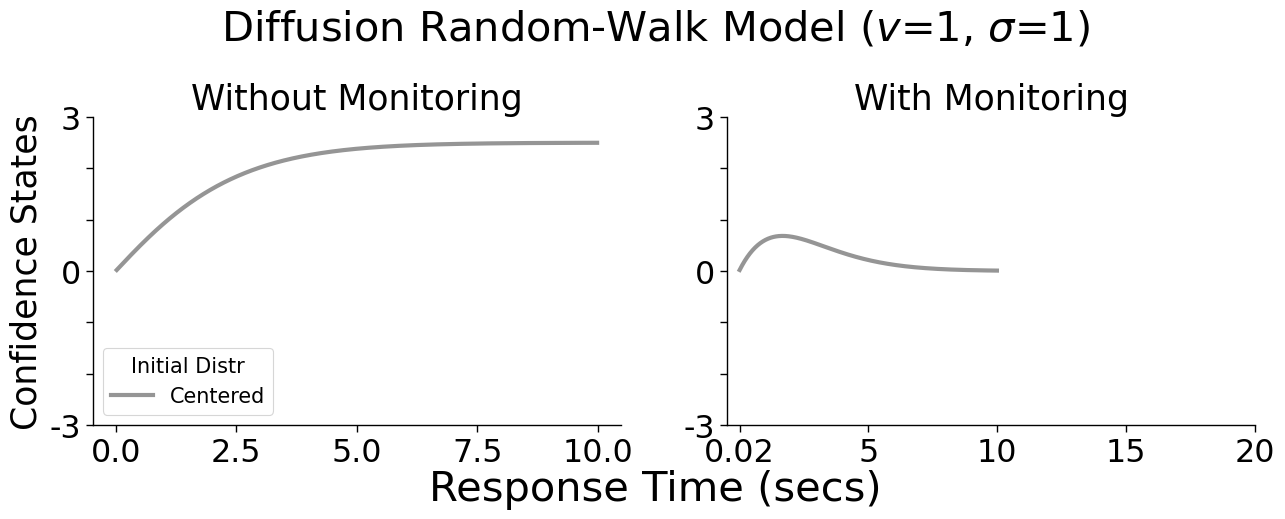

In [90]:
with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,2,figsize=(15,4))

    f = sns.lineplot(df_markov1_plot.query("time < 20  and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[0], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_markov1_internal_plot.query("time < 20  and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[1], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend(title="Initial Distr", title_fontsize=15, fontsize=15)
    f.set_title('Without Monitoring')
    f1.set_title('With Monitoring')
    #f.set_titles("{col_name}")
    f.figure.supxlabel("Response Time (secs)", y=-0.1)
    f.set_xlabel("")
    f1.set_xlabel("")
    f.set_ylabel("Confidence States")
    f1.set_ylabel("")
    f1.get_legend().remove()
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f1.set(yticks=[-3,-2,-1,0,1,2,3])
    f1.set_yticklabels(["-3","","","0","","","3"])
    #f1.set_xlim(2*steps, None)
    f1.set(xticks = [2*steps, 5, 10, 15, 20])
    f1.set_xticklabels([str(2*steps),"5","10","15","20"])
    f.figure.suptitle(f"Diffusion Random-Walk Model ($v$=1, $\sigma$={m_sigma[0][0]})", y = 1.15)
sns.despine()

with sns.plotting_context("paper",font_scale=2.6):

    f = sns.relplot(df_quantum1_internal_plot.query("time <= 8 and mu == '$v$=1, $\sigma$=2'"), x="time", y="value", 
                    style="prior", col="mu", color="black", aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend.set_title("Initial Distr")
    f.set_titles("{col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Confidence States")
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f.figure.suptitle("Quantum Random-Walk Model", y = 1.05)

with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,1,figsize=(15,4))

    #f = sns.lineplot(df_quantum1_plot.query("time < 20"), x="time", y="value", 
    #                hue="prior", ax=axs[0], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_quantum1_internal_plot.query("time < 40 and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs, lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f1.legend(title="Initial Distr", title_fontsize=15, fontsize=15)
    #f.set_title('External')
    #f1.set_title('Internal')
    #f.set_titles("{col_name}")
    #f.figure.supxlabel("Response Time (secs)", y=-0.1)
    f1.set_xlabel("Response Time (secs)")
    f1.set_ylabel("Mean Confidence States")
    #f1.set(yticks=[-3,-2,-1,0,1,2,3])
    #f1.set_yticklabels(["-3","","","0","","","3"])
    f1.figure.suptitle(f"Quantum Random-Walk Model ($v$=1, $\sigma$={q_sigma[0][0]})", y = 1.08)
sns.despine()

with sns.plotting_context("paper",font_scale=2.6):
    _, axs = plt.subplots(1,2,figsize=(15,4))

    f = sns.lineplot(df_quantum1_plot.query("time < 20 and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[0], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)

    f1 = sns.lineplot(df_quantum1_internal_plot.query("time < 20 and prior != '-High'"), x="time", y="value", 
                    hue="prior", ax=axs[1], lw=3, palette="Greys")#, aspect=2.4, height=5.5, kind="line",lw=4)
    f.legend(title="Initial Distr", title_fontsize=15, fontsize=15)
    f.set_title('Without Monitoring')
    f1.set_title('With Monitoring')
    #f.set_titles("{col_name}")
    f.figure.supxlabel("Response Time (secs)", y=-0.1)
    f.set_xlabel("")
    f1.set_xlabel("")
    f.set_ylabel("Confidence States")
    f1.set_ylabel("")
    f1.get_legend().remove()
    f.set(yticks=[-3,-2,-1,0,1,2,3])
    f.set_yticklabels(["-3","","","0","","","3"])
    f1.set(yticks=[-3,-2,-1,0,1,2,3])
    f1.set_yticklabels(["-3","","","0","","","3"])
    f1.set(xticks = [2*steps, 5, 10, 15, 20])
    f1.set_xticklabels([str(2*steps),"5","10","15","20"])

    f.figure.suptitle(f"Quantum Random-Walk Model ($v$=1, $\sigma$={q_sigma[0][0]})", y = 1.15)
sns.despine()

In [91]:
df_plot1 = pd.concat([df_quantum1_plot.assign(type="Quantum"), df_markov1_plot.assign(type="Markov")])
df_plot1

,prior,mu,time,value,type
0,Centered,"$v$=1, $\sigma$=5",0.02,0.001333,Quantum
1,Centered,"$v$=1, $\sigma$=5",0.03,0.003000,Quantum
2,Centered,"$v$=1, $\sigma$=5",0.04,0.005333,Quantum
3,Centered,"$v$=1, $\sigma$=5",0.05,0.008332,Quantum
4,Centered,"$v$=1, $\sigma$=5",0.06,0.011996,Quantum
...,...,...,...,...,...
993,Centered,"$v$=1, $\sigma$=1",9.95,2.497664,Markov
994,Centered,"$v$=1, $\sigma$=1",9.96,2.497684,Markov
995,Centered,"$v$=1, $\sigma$=1",9.97,2.497703,Markov
996,Centered,"$v$=1, $\sigma$=1",9.98,2.497722,Markov


In [92]:
df_plot_internal1 = pd.concat([df_quantum1_internal_plot.assign(type="Quantum"), df_markov1_internal_plot.assign(type="Markov")])
df_plot_internal1_c = pd.concat([df_quantum1_internal_plot_c.assign(type="Quantum"), df_markov1_internal_plot_c.assign(type="Markov")])
df_plot_internal1_w = pd.concat([df_quantum1_internal_plot_w.assign(type="Quantum"), df_markov1_internal_plot_w.assign(type="Markov")])
df_plot_internal1_c

,prior,mu,time,value,type
0,Centered,"$v$=1, $\sigma$=5",0.02,0.334020,Quantum
1,Centered,"$v$=1, $\sigma$=5",0.03,0.334922,Quantum
2,Centered,"$v$=1, $\sigma$=5",0.04,0.336249,Quantum
3,Centered,"$v$=1, $\sigma$=5",0.05,0.338061,Quantum
4,Centered,"$v$=1, $\sigma$=5",0.06,0.340434,Quantum
...,...,...,...,...,...
993,Centered,"$v$=1, $\sigma$=1",9.95,0.008211,Markov
994,Centered,"$v$=1, $\sigma$=1",9.96,0.008151,Markov
995,Centered,"$v$=1, $\sigma$=1",9.97,0.008091,Markov
996,Centered,"$v$=1, $\sigma$=1",9.98,0.008031,Markov


In [93]:
custom_color = ["Green","Orange", "Red"]

In [94]:
df_plot1

,prior,mu,time,value,type
0,Centered,"$v$=1, $\sigma$=5",0.02,0.001333,Quantum
1,Centered,"$v$=1, $\sigma$=5",0.03,0.003000,Quantum
2,Centered,"$v$=1, $\sigma$=5",0.04,0.005333,Quantum
3,Centered,"$v$=1, $\sigma$=5",0.05,0.008332,Quantum
4,Centered,"$v$=1, $\sigma$=5",0.06,0.011996,Quantum
...,...,...,...,...,...
993,Centered,"$v$=1, $\sigma$=1",9.95,2.497664,Markov
994,Centered,"$v$=1, $\sigma$=1",9.96,2.497684,Markov
995,Centered,"$v$=1, $\sigma$=1",9.97,2.497703,Markov
996,Centered,"$v$=1, $\sigma$=1",9.98,2.497722,Markov


/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



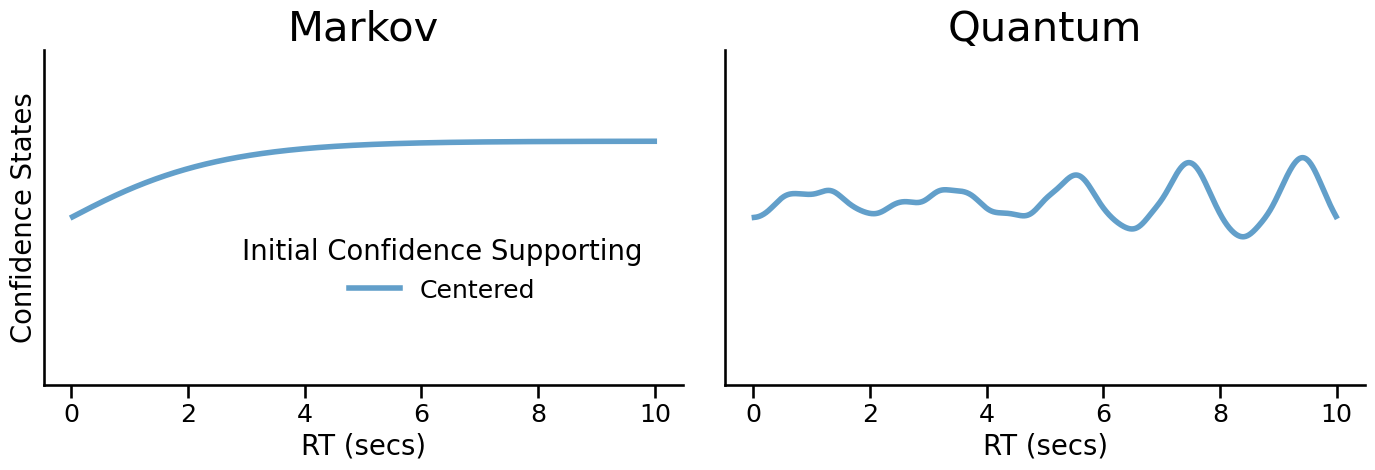

In [95]:
with sns.plotting_context("talk", font_scale=1.1):
    f = sns.relplot(df_plot1,#.query("(mu =='$v$=1, $\sigma$=2')"),#.assign(prior=lambda df:df.prior.map({"+High":"Correct Response", "-High":"Incorrect Response", "Centered":"No Response", "Opposite":"Both Responses"})),
                     x="time", y="value", 
                    col_order=["Markov", "Quantum"], hue = "prior", #hue_order= ["Correct Response", "No Response" ,"Incorrect Response", "Both Responses"],
                    #palette=custom_color,
                    col="type", color="black", aspect=1.5, height=5, kind="line",lw=4, alpha=0.7)
    f.legend.set_title("Initial Confidence Supporting")
    f.legend.set_bbox_to_anchor((0.39,0.4))
    f.set_titles("{col_name}", size=30)
    f.set_xlabels("RT (secs)")
    #f.axes[1,0].set_ylabel("CS (Quantum)")
    #f.axes[1,0].set_title("")
    #f.axes[1,1].set_title("")
    #f.axes[1,2].set_title("")
    #f.axes[1,3].set_title("")
    #f.axes[0,0].set_ylabel("CS (Diffusion)")
    f.set(yticks=[])
    #f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-5.5, 5.5))
    f.set_ylabels("Confidence States")


with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_plot_internal1.query("(mu =='$v$=1, $\sigma$=2')"),#.assign(prior=lambda df:df.prior.map({"+High":"Correct Response", "-High":"Incorrect Response", "Centered":"No Response"})),
                     x="time", y="value", 
                    col_order=["Diffusion", "Quantum"], hue = "prior", hue_order= ["Correct Response", "No Response" ,"Incorrect Response"],
                    palette=custom_color,
                    col="type", color="black", aspect=1.5, height=5, kind="line",lw=4, alpha=0.7, facet_kws={"sharey":False})
    f.legend.set_title("Initial Confidence Supporting")
    f.legend.set_bbox_to_anchor((0.39,0.4))
    f.set_titles("{col_name}")
    f.set_xlabels("RT (secs)")
    #f.axes[1,0].set_ylabel("CS (Quantum)")
    #f.axes[1,0].set_title("")
    #f.axes[1,1].set_title("")
    #f.axes[1,2].set_title("")
    #f.axes[1,3].set_title("")
    #f.axes[0,0].set_ylabel("CS (Diffusion)")
    f.set(yticks=[])
    #f.set_yticklabels(["-3","","","0","","","3"])
    f.set(ylim=(-5.5, 5.5))
    f.set_ylabels("Confidence States")


/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



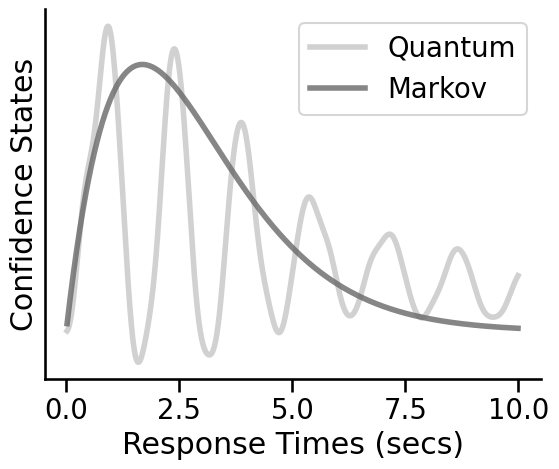

In [96]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.lineplot(df_plot_internal1,#.query("prior == 'Centered'"),#.assign(prior=lambda df:df.prior.map({"+High":"Correct Response", "-High":"Incorrect Response", "Centered":"No Response"})),
                     x="time", y="value", 
                    #col_order=["Diffusion", "Quantum"],# hue = "prior", hue_order= ["Correct Response", "No Response" ,"Incorrect Response"],
                    #palette=custom_color,
                    palette="Greys",
                    hue="type", #hue_order=["Markov", "Quantum"],
                    #aspect=1.5, height=5, 
                    #kind="line",
                    lw=4, 
                    alpha=0.8, 
                    #facet_kws={"sharey":False}
                    )
    f.get_legend().set_title("")
    #f.set_title("Correct Response")
    #f.legend.set_bbox_to_anchor((0.39,0.4))
    #f.set_titles("{col_name}")
    f.set_xlabel("Response Times (secs)")
    #f.axes[1,0].set_ylabel("CS (Quantum)")
    #f.axes[1,0].set_title("")
    #f.axes[1,1].set_title("")
    #f.axes[1,2].set_title("")
    #f.axes[1,3].set_title("")
    #f.axes[0,0].set_ylabel("CS (Diffusion)")
    f.set(yticks=[])
    #f.set_yticklabels(["-3","","","0","","","3"])
    #f.set(ylim=(-5.5, 5.5))
    f.set_ylabel("Confidence States")
sns.despine()

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning:

When grouping with a length-1 list-like

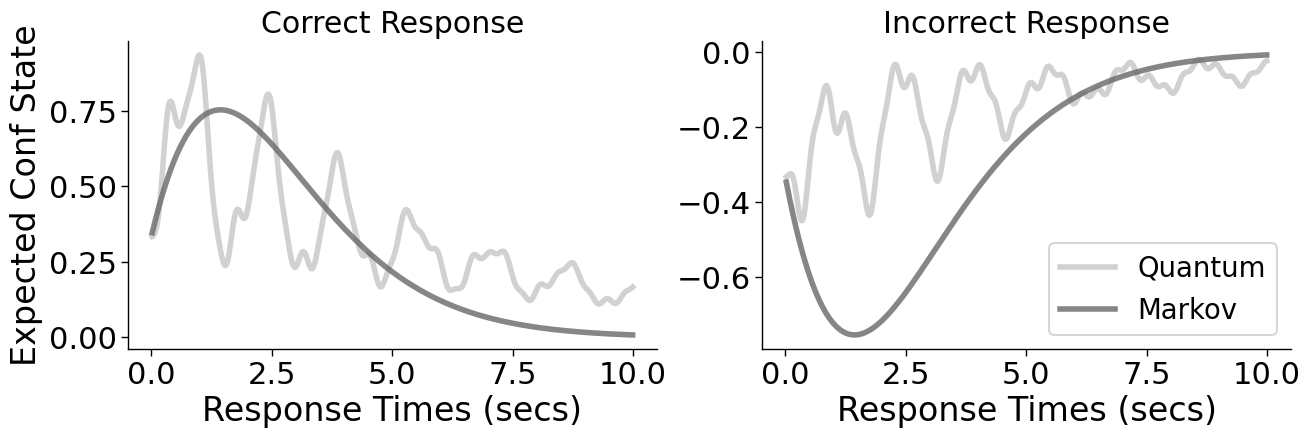

In [101]:
fig, axs = plt.subplots(1,2, figsize=(15,4))
with sns.plotting_context("talk", font_scale=1.2):
    for df_plot_t, ax, tl in zip([df_plot_internal1_c, df_plot_internal1_w],axs,["Correct", "Incorrect"]):
        f = sns.lineplot(df_plot_t,#.query("prior == 'Centered'"),#.assign(prior=lambda df:df.prior.map({"+High":"Correct Response", "-High":"Incorrect Response", "Centered":"No Response"})),
                     x="time", y="value", 
                    #col_order=["Diffusion", "Quantum"],# hue = "prior", hue_order= ["Correct Response", "No Response" ,"Incorrect Response"],
                    #palette=custom_color,
                    palette="Greys",
                    hue="type", #hue_order=["Markov", "Quantum"],
                    #aspect=1.5, height=5, 
                    #kind="line",
                    lw=4, 
                    alpha=0.8, 
                    ax=ax
                    #facet_kws={"sharey":False}
                    )
        f.get_legend().set_title("")
        f.get_legend().set_visible(False)
        f.set_title(f"{tl} Response")
        #f.legend.set_bbox_to_anchor((0.39,0.4))
        #f.set_titles("{col_name}")
        f.set_xlabel("Response Times (secs)")
        f.set_ylabel("")
        #f.axes[1,0].set_ylabel("CS (Quantum)")
        #f.axes[1,0].set_title("")
        #f.axes[1,1].set_title("")
        #f.axes[1,2].set_title("")
        #f.axes[1,3].set_title("")
        #f.axes[0,0].set_ylabel("CS (Diffusion)")
        #f.set(yticks=[])
        #f.set_yticklabels(["-3","","","0","","","3"])
        #f.set(ylim=(-5.5, 5.5))
axs[1].get_legend().set_visible(True)
axs[0].set_ylabel("Expected Conf State")
sns.despine()

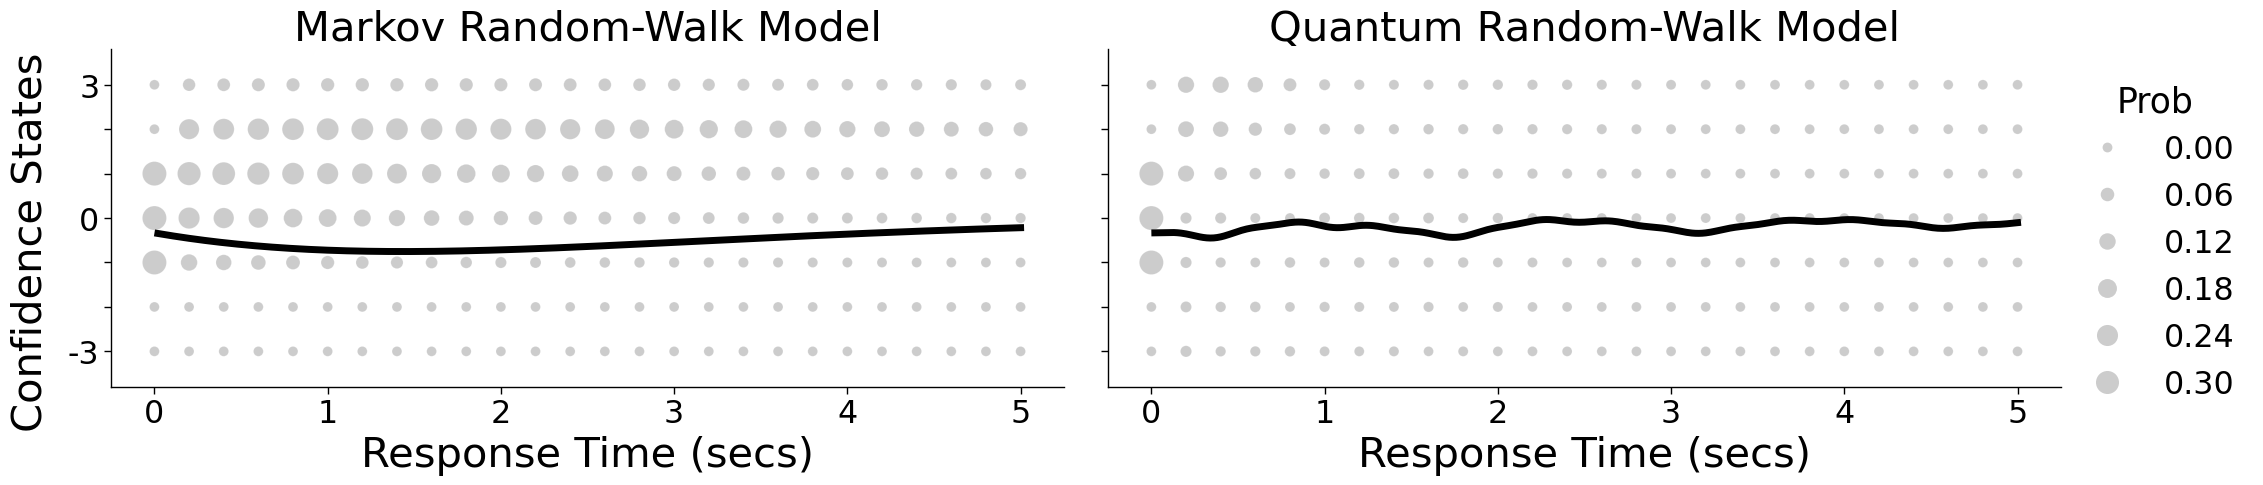

In [98]:
with sns.plotting_context("paper",font_scale=2.6):
    f = sns.relplot(df_plot
                    .query("time <= 5 ") #prior == 'Centered' and 
                    ,alpha=0.2, col="type", col_wrap=2, sizes=(50,300), 
    x="time", y="states",size="value", color="Black", aspect=2, height=5.3)
    

sns.lineplot(df_plot_internal1_w.query("type=='Markov'  and time <= 5 "), #prior == 'Centered' and 
                    x="time", y="value", 
                    color="black", 
                    lw=5, ax=f.axes[0], legend=False)

sns.lineplot(df_plot_internal1_w.query("type=='Quantum'  and time <= 5 "), #prior == 'Centered' and 
                    x="time", y="value", 
                    color="black", 
                    lw=5, ax=f.axes[1], legend=False)

f.set_titles("{col_name}", size=30)
f.legend.set_title("Prob")
f.set_xlabels("Response Time (secs)", fontsize=30)
f.set_ylabels("")
f.figure.supylabel("Confidence States", fontsize=30)
f.set(yticks=[-3,-2,-1,0,1,2,3])
f.set_yticklabels(["-3","","","0","","","3"])
f.set(ylim=(-3.8, 3.8))

#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()